# Convolutional Neural Network – Notebook Elma

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import time

2026-04-14 08:16:55.494283: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
np.random.seed(42)
tf.random.set_seed(42)

## 1 Helper functions

In [4]:
def plot_samples(xdata, ydata, amount=10):
    for number in range(10):
        indices = np.random.choice(np.where(ydata == number)[0], size=amount, replace=False)
        fig = plt.figure(figsize=(20, 6))
        fig.suptitle(f"Beispiele für Nummer {number}:")
        nplt = 1
        for index in indices:
            ax = fig.add_subplot(4, 10, nplt)
            ax.axis('off')
            plt.imshow(xdata[index])
            nplt += 1
        plt.show()

## 2 MNIST Daten laden und analysieren

In [6]:
# Daten laden
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Anzahl der Trainings- und Testdaten
print(f"x_train: {x_train.shape}, x_test: {x_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

# Daten normalisieren
x_train = x_train / 255.0
x_test = x_test / 255.0
 
# Anzahl und Verteilung der einzelnen Ziffern
unique, counts = np.unique(y_train, return_counts=True)
print(f"Verteilung (Trainingsdaten): {dict(zip(unique, counts))}")

# Minimun und Maximum der Features und Labels
print(f"x_train min/max: {x_train.min()}, {x_train.max()}")
print(f"y_train min/max: {y_train.min()}, {y_train.max()}")


x_train: (60000, 28, 28), x_test: (10000, 28, 28)
y_train: (60000,), y_test: (10000,)
Verteilung (Trainingsdaten): {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}
x_train min/max: 0.0, 1.0
y_train min/max: 0, 9


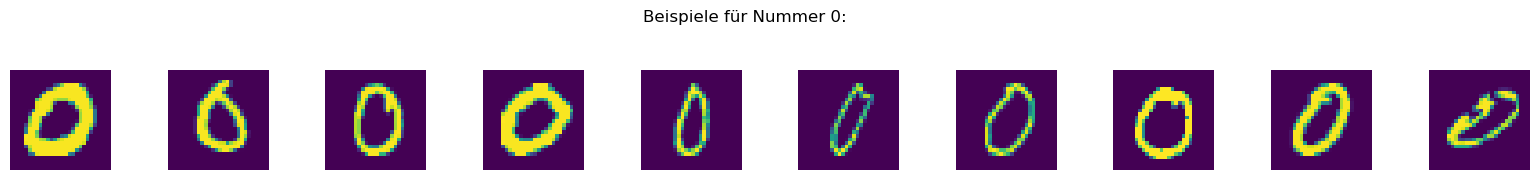

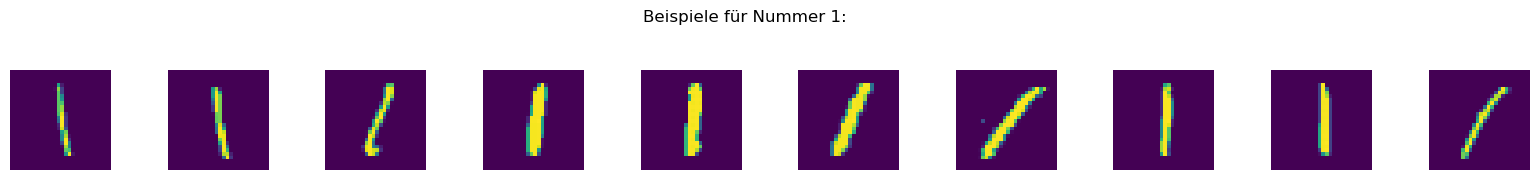

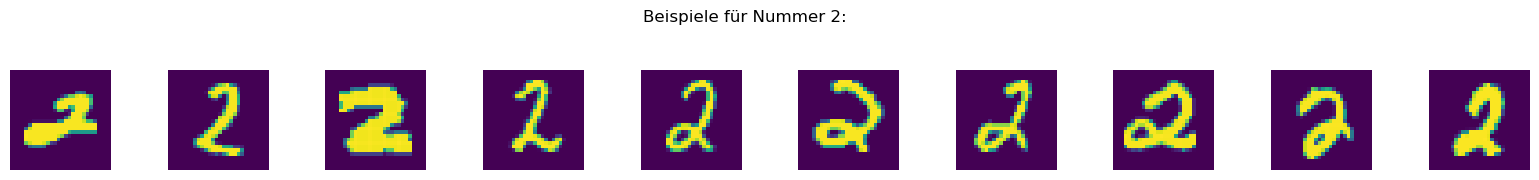

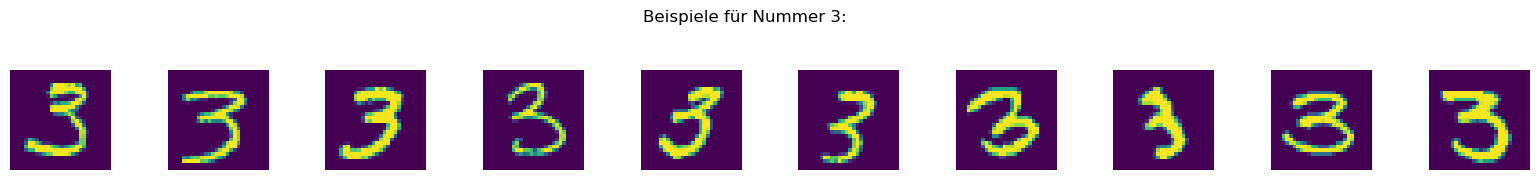

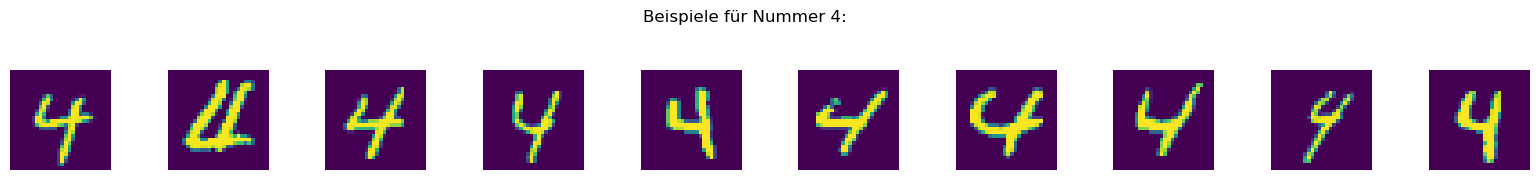

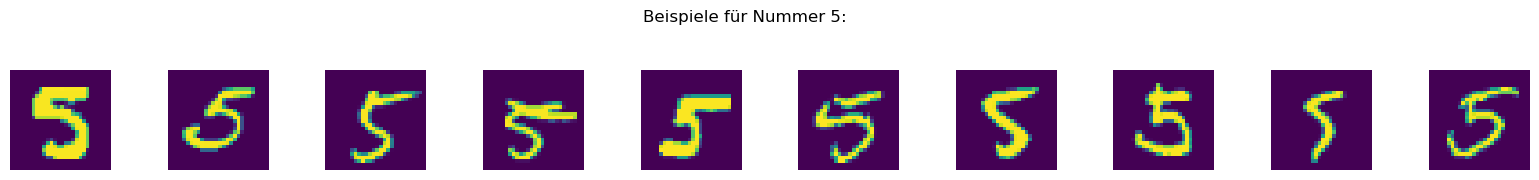

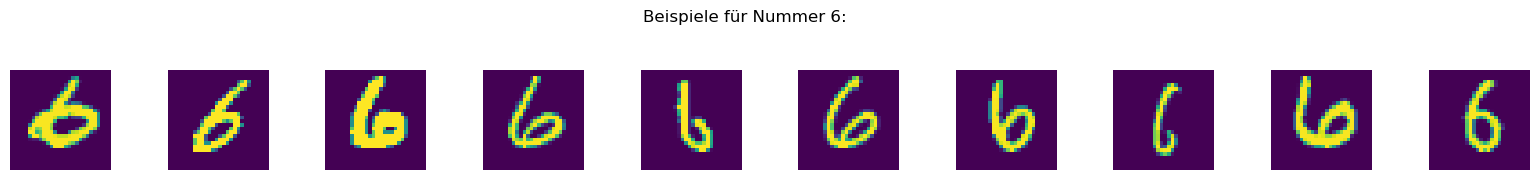

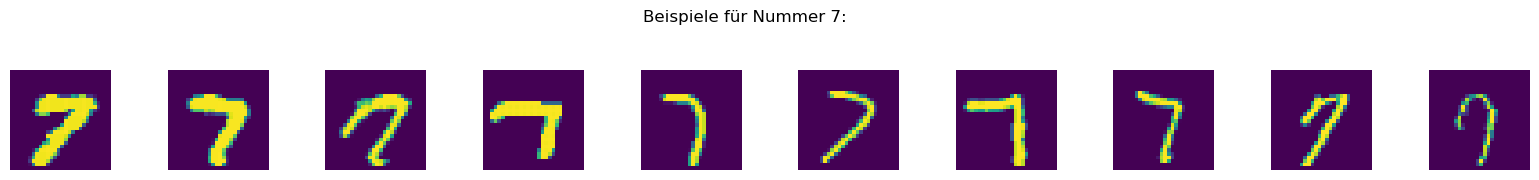

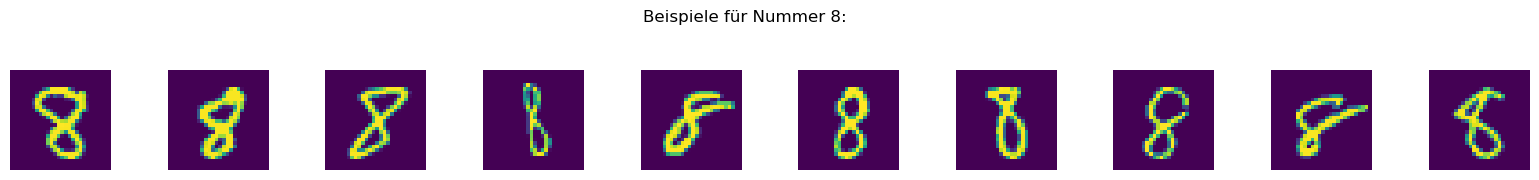

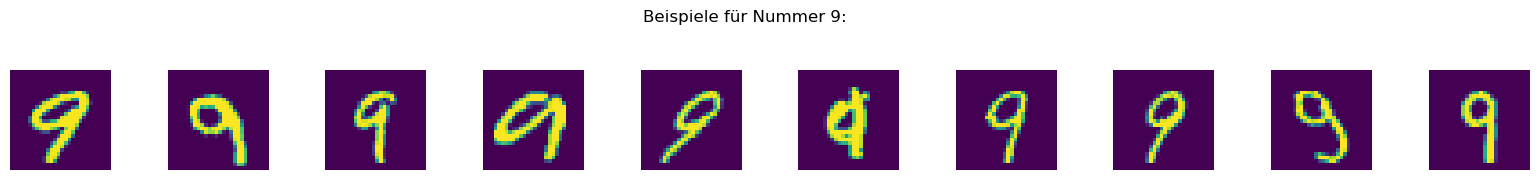

In [6]:
# Einige Ziffern beispielhaft plotten
plot_samples(x_train, y_train)

## Plot der Trainings- und Testdaten

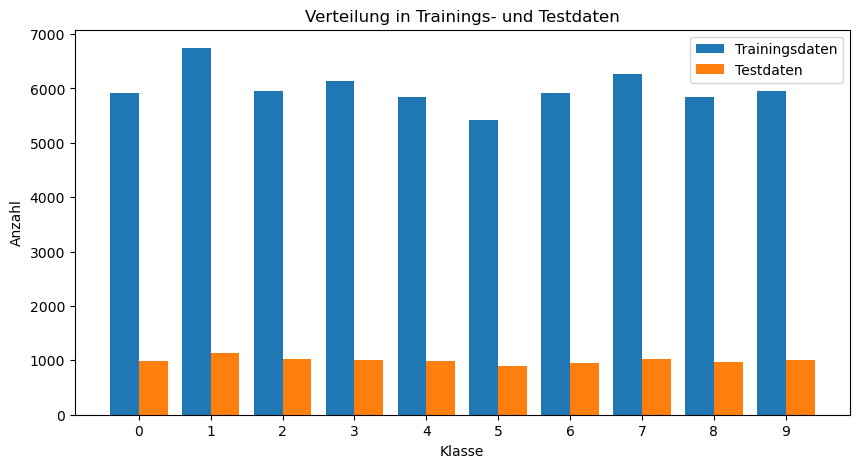

In [39]:
# Verteilung der Trainings- und Testdaten als Plot
train_anzahl = np.bincount(y_train)
test_anzahl = np.bincount(y_test)
labels = np.arange(10)
plt.figure(figsize=(10, 5))
width = 0.4
plt.bar(labels - width / 2, train_anzahl, width=width, label="Trainingsdaten")
plt.bar(labels + width / 2, test_anzahl, width=width, label="Testdaten")
plt.xticks(labels)
plt.xlabel("Klasse")
plt.ylabel("Anzahl")
plt.title("Verteilung in Trainings- und Testdaten")
plt.legend()
plt.show()

## 3 Eigenes CNN-Modell

In [7]:
def elma_model_neu():
    """
    CNN for 28x28 image classification (Functional API).

    Architecture:
    Input -> Conv2D -> Conv2D -> MaxPooling -> Dropout -> Conv2D -> Conv2D -> MaxPooling
          -> Dropout -> Flatten -> Dense -> Dropout -> Softmax
    """
    # ------------------------------------------------------------
    # Input layer
    # ------------------------------------------------------------
    inputs = keras.layers.Input(shape=(28, 28, 1), name="input_image")

    # ------------------------------------------------------------
    # Feature extraction
    # ------------------------------------------------------------
    x = keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same",
        name="conv_1",
        strides=(1,1)
    )(inputs)

    x = keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same",
        name="conv_2",
        strides=(1,1)
    )(x)

    x = keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        name="maxpool_1",
        strides=(2,2)
    )(x)

    x = keras.layers.Dropout(0.25, name="dropout")(x)

    
    x = keras.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same",
        name="conv_3",
        strides=(1,1)
    )(x)


    x = keras.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same",
        name="conv_4",
        strides=(1,1)
    )(x)

    x = keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        name="pool_2",
        strides=(2,2)
    )(x)

    x = keras.layers.Dropout(0.25, name="dropout_1")(x)

    # ------------------------------------------------------------
    # Classification head
    # ------------------------------------------------------------
    x = keras.layers.Flatten(name="flatten")(x)
    x = keras.layers.Dense(units=128, activation="relu", name="dense_1")(x)
    x = keras.layers.Dropout(0.5, name="dropout_2")(x)

    # ------------------------------------------------------------
    # Output layer
    # ------------------------------------------------------------
    outputs = keras.layers.Dense(units=10, activation="softmax", name="output")(x)

    # ------------------------------------------------------------
    # Build and compile model
    # ------------------------------------------------------------
    model = keras.Model(inputs=inputs, outputs=outputs, name="elma_cnn_model")
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.summary()
    return model

In [8]:
tf.keras.backend.clear_session()
model1 = elma_model_neu()

Model: "elma_cnn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 28, 28, 1)]       0         
                                                                 
 conv_1 (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 conv_2 (Conv2D)             (None, 28, 28, 64)        18496     
                                                                 
 maxpool_1 (MaxPooling2D)    (None, 14, 14, 64)        0         
                                                                 
 conv_3 (Conv2D)             (None, 14, 14, 32)        18464     
                                                                 
 conv_4 (Conv2D)             (None, 14, 14, 64)        18496     
                                                                 
 maxpool_2 (MaxPooling2D)    (None, 7, 7, 64)       

## 4 Batch-Size-Vergleich

In [10]:
# Training mit batch_size=8
tf.keras.backend.clear_session()
model1 = elma_model_neu()
batchsize_8 = model1.fit(x_train, y_train, batch_size=32, epochs=10)

Model: "elma_cnn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 28, 28, 1)]       0         
                                                                 
 conv_1 (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 conv_2 (Conv2D)             (None, 28, 28, 64)        18496     
                                                                 
 maxpool_1 (MaxPooling2D)    (None, 14, 14, 64)        0         
                                                                 
 conv_3 (Conv2D)             (None, 14, 14, 32)        18464     
                                                                 
 conv_4 (Conv2D)             (None, 14, 14, 64)        18496     
                                                                 
 maxpool_2 (MaxPooling2D)    (None, 7, 7, 64)       

In [11]:
# Training mit batch_size=16
tf.keras.backend.clear_session()
model1 = elma_model_neu()
batchsize_16 = model1.fit(x_train, y_train, batch_size=16, epochs=10)

Model: "elma_cnn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 28, 28, 1)]       0         
                                                                 
 conv_1 (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 conv_2 (Conv2D)             (None, 28, 28, 64)        18496     
                                                                 
 maxpool_1 (MaxPooling2D)    (None, 14, 14, 64)        0         
                                                                 
 conv_3 (Conv2D)             (None, 14, 14, 32)        18464     
                                                                 
 conv_4 (Conv2D)             (None, 14, 14, 64)        18496     
                                                                 
 maxpool_2 (MaxPooling2D)    (None, 7, 7, 64)       

In [9]:
# Training mit batch_size=32
tf.keras.backend.clear_session()
model1 = elma_model_neu()
batchsize_32 = model1.fit(x_train, y_train, batch_size=32, epochs=10)

Model: "elma_cnn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 28, 28, 1)]       0         
                                                                 
 conv_1 (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 conv_2 (Conv2D)             (None, 28, 28, 64)        18496     
                                                                 
 maxpool_1 (MaxPooling2D)    (None, 14, 14, 64)        0         
                                                                 
 conv_3 (Conv2D)             (None, 14, 14, 32)        18464     
                                                                 
 conv_4 (Conv2D)             (None, 14, 14, 64)        18496     
                                                                 
 maxpool_2 (MaxPooling2D)    (None, 7, 7, 64)       

In [10]:
# Training mit batch_size=64
tf.keras.backend.clear_session()
model1 = elma_model_neu()
batchsize = model1.fit(x_train, y_train, batch_size=64, epochs=10)

Model: "elma_cnn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 28, 28, 1)]       0         
                                                                 
 conv_1 (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 conv_2 (Conv2D)             (None, 28, 28, 64)        18496     
                                                                 
 maxpool_1 (MaxPooling2D)    (None, 14, 14, 64)        0         
                                                                 
 conv_3 (Conv2D)             (None, 14, 14, 32)        18464     
                                                                 
 conv_4 (Conv2D)             (None, 14, 14, 64)        18496     
                                                                 
 maxpool_2 (MaxPooling2D)    (None, 7, 7, 64)       

In [11]:
# Training mit batch_size=128
tf.keras.backend.clear_session()
model1 = elma_model_neu()
batchsize_128 = model1.fit(x_train, y_train, batch_size=128, epochs=10)

Model: "elma_cnn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 28, 28, 1)]       0         
                                                                 
 conv_1 (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 conv_2 (Conv2D)             (None, 28, 28, 64)        18496     
                                                                 
 maxpool_1 (MaxPooling2D)    (None, 14, 14, 64)        0         
                                                                 
 conv_3 (Conv2D)             (None, 14, 14, 32)        18464     
                                                                 
 conv_4 (Conv2D)             (None, 14, 14, 64)        18496     
                                                                 
 maxpool_2 (MaxPooling2D)    (None, 7, 7, 64)       

In [12]:
# Training mit batch_size=256
tf.keras.backend.clear_session()
model1 = elma_model_neu()
batchsize_256 = model1.fit(x_train, y_train, batch_size=256, epochs=10)

Model: "elma_cnn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 28, 28, 1)]       0         
                                                                 
 conv_1 (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 conv_2 (Conv2D)             (None, 28, 28, 64)        18496     
                                                                 
 maxpool_1 (MaxPooling2D)    (None, 14, 14, 64)        0         
                                                                 
 conv_3 (Conv2D)             (None, 14, 14, 32)        18464     
                                                                 
 conv_4 (Conv2D)             (None, 14, 14, 64)        18496     
                                                                 
 maxpool_2 (MaxPooling2D)    (None, 7, 7, 64)       

In [13]:
# Training mit batch_size=512
tf.keras.backend.clear_session()
model1 = elma_model_neu()
batchsize_512 = model1.fit(x_train, y_train, batch_size=512, epochs=10)

Model: "elma_cnn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 28, 28, 1)]       0         
                                                                 
 conv_1 (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 conv_2 (Conv2D)             (None, 28, 28, 64)        18496     
                                                                 
 maxpool_1 (MaxPooling2D)    (None, 14, 14, 64)        0         
                                                                 
 conv_3 (Conv2D)             (None, 14, 14, 32)        18464     
                                                                 
 conv_4 (Conv2D)             (None, 14, 14, 64)        18496     
                                                                 
 maxpool_2 (MaxPooling2D)    (None, 7, 7, 64)       

### Finales Modell trainieren

In [14]:
# Finales Modell trainieren
model1 = elma_model_neu()
model1.fit(x_train, y_train, batch_size=32, epochs=10)

# Modell anhand von Testdaten bewerten
print('\nperformance on test data:')
model1.evaluate(x_test, y_test)

Model: "elma_cnn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 28, 28, 1)]       0         
                                                                 
 conv_1 (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 conv_2 (Conv2D)             (None, 28, 28, 64)        18496     
                                                                 
 maxpool_1 (MaxPooling2D)    (None, 14, 14, 64)        0         
                                                                 
 conv_3 (Conv2D)             (None, 14, 14, 32)        18464     
                                                                 
 conv_4 (Conv2D)             (None, 14, 14, 64)        18496     
                                                                 
 maxpool_2 (MaxPooling2D)    (None, 7, 7, 64)       

[0.020921869203448296, 0.9940999746322632]

## 5 Validierung

#### Vergleich von validation split 10% und 20%

In [15]:
# Mit 20% validation split
tf.keras.backend.clear_session()
model_validieren = elma_model_neu()

start = time.time()

validierung_20 = model_validieren.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=10,
    validation_split=0.2
)

time_20 = time.time() - start

Model: "elma_cnn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 28, 28, 1)]       0         
                                                                 
 conv_1 (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 conv_2 (Conv2D)             (None, 28, 28, 64)        18496     
                                                                 
 maxpool_1 (MaxPooling2D)    (None, 14, 14, 64)        0         
                                                                 
 conv_3 (Conv2D)             (None, 14, 14, 32)        18464     
                                                                 
 conv_4 (Conv2D)             (None, 14, 14, 64)        18496     
                                                                 
 maxpool_2 (MaxPooling2D)    (None, 7, 7, 64)       

In [16]:
# Mit 10% validation split
tf.keras.backend.clear_session()
model_validieren = elma_model_neu()

start = time.time()

validierung_10 = model_validieren.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=10,
    validation_split=0.1
)

time_10 = time.time() - start

Model: "elma_cnn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 28, 28, 1)]       0         
                                                                 
 conv_1 (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 conv_2 (Conv2D)             (None, 28, 28, 64)        18496     
                                                                 
 maxpool_1 (MaxPooling2D)    (None, 14, 14, 64)        0         
                                                                 
 conv_3 (Conv2D)             (None, 14, 14, 32)        18464     
                                                                 
 conv_4 (Conv2D)             (None, 14, 14, 64)        18496     
                                                                 
 maxpool_2 (MaxPooling2D)    (None, 7, 7, 64)       

In [17]:
print(" Vergleich Validation Split ")

print(f"10% -> Validierung_accuracy: {validierung_10.history['val_accuracy'][-1]:.4f}, "
      f"Validierung_loss: {validierung_10.history['val_loss'][-1]:.4f}, "
      f"Zeit: {time_10:.2f}s")

print(f"20% -> Validierung_accuracy: {validierung_20.history['val_accuracy'][-1]:.4f}, "
      f"Validierung_loss: {validierung_20.history['val_loss'][-1]:.4f}, "
      f"Zeit: {time_20:.2f}s")

 Vergleich Validation Split 
10% -> Validierung_accuracy: 0.9917, Validierung_loss: 0.0429, Zeit: 321.97s
20% -> Validierung_accuracy: 0.9927, Validierung_loss: 0.0327, Zeit: 290.54s


#### Weiter machen mit 20% validation split. Die Accuracy ist nur minimal besser im Vergleich zum loss und der Zeit. 

In [18]:
tf.keras.backend.clear_session()
model_validieren = elma_model_neu()

# 1. Training
start = time.time()
training_1 = model_validieren.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=10,
    validation_split=0.2
)
time_1 = time.time() - start

Model: "elma_cnn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 28, 28, 1)]       0         
                                                                 
 conv_1 (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 conv_2 (Conv2D)             (None, 28, 28, 64)        18496     
                                                                 
 maxpool_1 (MaxPooling2D)    (None, 14, 14, 64)        0         
                                                                 
 conv_3 (Conv2D)             (None, 14, 14, 32)        18464     
                                                                 
 conv_4 (Conv2D)             (None, 14, 14, 64)        18496     
                                                                 
 maxpool_2 (MaxPooling2D)    (None, 7, 7, 64)       

In [19]:
# Ein weiterer Trainingschritt
start = time.time()
training_2 = model_validieren.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=10,
    validation_split=0.2
)
time_2 = time.time() - start

Epoch 1/10
1500/1500 [==============================] - 30s 20ms/step - loss: 0.0200 - accuracy: 0.9938 - val_loss: 0.0339 - val_accuracy: 0.9927
Epoch 2/10
1500/1500 [==============================] - 31s 20ms/step - loss: 0.0221 - accuracy: 0.9934 - val_loss: 0.0343 - val_accuracy: 0.9925
Epoch 3/10
1500/1500 [==============================] - 30s 20ms/step - loss: 0.0215 - accuracy: 0.9935 - val_loss: 0.0271 - val_accuracy: 0.9928
Epoch 4/10
1500/1500 [==============================] - 30s 20ms/step - loss: 0.0174 - accuracy: 0.9946 - val_loss: 0.0300 - val_accuracy: 0.9940
Epoch 5/10
1500/1500 [==============================] - 30s 20ms/step - loss: 0.0166 - accuracy: 0.9949 - val_loss: 0.0407 - val_accuracy: 0.9923
Epoch 6/10
1500/1500 [==============================] - 29s 20ms/step - loss: 0.0182 - accuracy: 0.9945 - val_loss: 0.0322 - val_accuracy: 0.9932
Epoch 7/10
1500/1500 [==============================] - 30s 20ms/step - loss: 0.0155 - accuracy: 0.9952 - val_loss: 0.0347 -

In [22]:
# Ein weiterer Trainingsschritt
start = time.time()
training_3 = model_validieren.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=10,
    validation_split=0.2
)
time_3 = time.time() - start

Epoch 1/10
1500/1500 [==============================] - 29s 20ms/step - loss: 0.0087 - accuracy: 0.9972 - val_loss: 0.0658 - val_accuracy: 0.9929
Epoch 2/10
1500/1500 [==============================] - 30s 20ms/step - loss: 0.0140 - accuracy: 0.9963 - val_loss: 0.0376 - val_accuracy: 0.9949
Epoch 3/10
1500/1500 [==============================] - 30s 20ms/step - loss: 0.0121 - accuracy: 0.9966 - val_loss: 0.0500 - val_accuracy: 0.9937
Epoch 4/10
1500/1500 [==============================] - 30s 20ms/step - loss: 0.0130 - accuracy: 0.9962 - val_loss: 0.0429 - val_accuracy: 0.9931
Epoch 5/10
1500/1500 [==============================] - 30s 20ms/step - loss: 0.0091 - accuracy: 0.9970 - val_loss: 0.0649 - val_accuracy: 0.9918
Epoch 6/10
1500/1500 [==============================] - 29s 19ms/step - loss: 0.0104 - accuracy: 0.9971 - val_loss: 0.0489 - val_accuracy: 0.9923
Epoch 7/10
1500/1500 [==============================] - 30s 20ms/step - loss: 0.0143 - accuracy: 0.9960 - val_loss: 0.0433 -

In [23]:
# Ein weiterer Trainingsschritt
start = time.time()
training_4 = model_validieren.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=10,
    validation_split=0.2
)
time_4 = time.time() - start

Epoch 1/10
1500/1500 [==============================] - 29s 19ms/step - loss: 0.0100 - accuracy: 0.9972 - val_loss: 0.0455 - val_accuracy: 0.9936
Epoch 2/10
1500/1500 [==============================] - 30s 20ms/step - loss: 0.0108 - accuracy: 0.9969 - val_loss: 0.0533 - val_accuracy: 0.9939
Epoch 3/10
1500/1500 [==============================] - 29s 20ms/step - loss: 0.0103 - accuracy: 0.9967 - val_loss: 0.0607 - val_accuracy: 0.9929
Epoch 4/10
1500/1500 [==============================] - 29s 19ms/step - loss: 0.0160 - accuracy: 0.9958 - val_loss: 0.0532 - val_accuracy: 0.9937
Epoch 5/10
1500/1500 [==============================] - 29s 19ms/step - loss: 0.0106 - accuracy: 0.9970 - val_loss: 0.0515 - val_accuracy: 0.9932
Epoch 6/10
1500/1500 [==============================] - 30s 20ms/step - loss: 0.0112 - accuracy: 0.9968 - val_loss: 0.0521 - val_accuracy: 0.9938
Epoch 7/10
1500/1500 [==============================] - 29s 20ms/step - loss: 0.0119 - accuracy: 0.9969 - val_loss: 0.0552 -

## 5.1 Plots zum Trainingsverlauf

In [24]:
print(" Trainingsschritte ")

print(f"Step 1 -> Validierung_acc: {training_1.history['val_accuracy'][-1]:.4f}, "
      f"Validierung_loss: {training_1.history['val_loss'][-1]:.4f}, "
      f"Zeit: {time_1:.2f}s")

print(f"Step 2 -> Validierung_acc: {training_2.history['val_accuracy'][-1]:.4f}, "
      f"Validierung_loss: {training_2.history['val_loss'][-1]:.4f}, "
      f"Zeit: {time_2:.2f}s")

print(f"Step 3 -> Validierung_acc: {training_3.history['val_accuracy'][-1]:.4f}, "
      f"Validierung_loss: {training_3.history['val_loss'][-1]:.4f}, "
      f"Zeit: {time_3:.2f}s")

print(f"Step 4 -> Validierung_acc: {training_4.history['val_accuracy'][-1]:.4f}, "
      f"Validierung_loss: {training_4.history['val_loss'][-1]:.4f}, "
      f"Zeit: {time_3:.2f}s")

 Trainingsschritte 
Step 1 -> Validierung_acc: 0.9930, Validierung_loss: 0.0282, Zeit: 298.22s
Step 2 -> Validierung_acc: 0.9937, Validierung_loss: 0.0361, Zeit: 298.61s
Step 3 -> Validierung_acc: 0.9936, Validierung_loss: 0.0435, Zeit: 294.97s
Step 4 -> Validierung_acc: 0.9929, Validierung_loss: 0.0603, Zeit: 294.97s


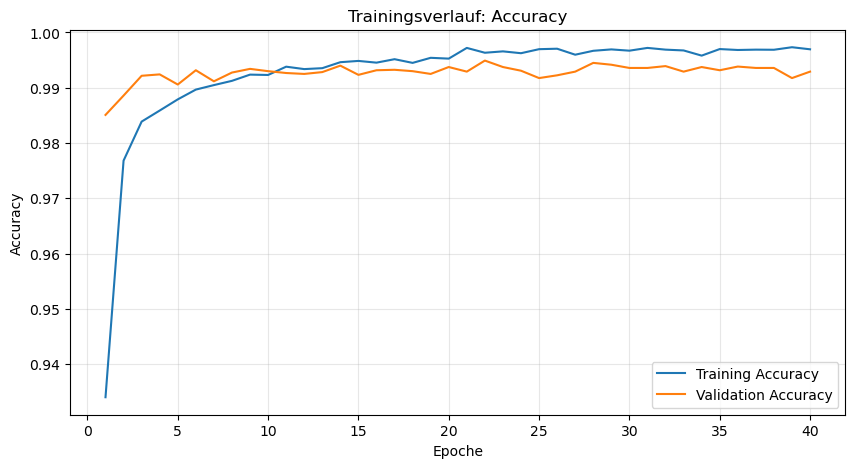

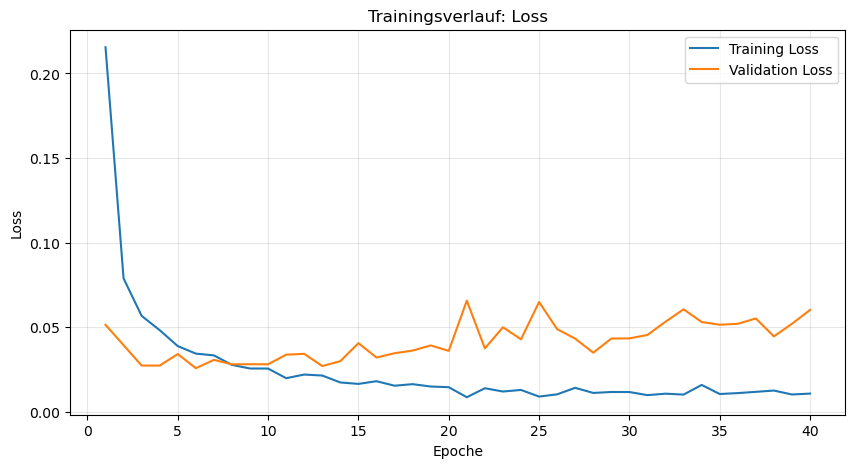

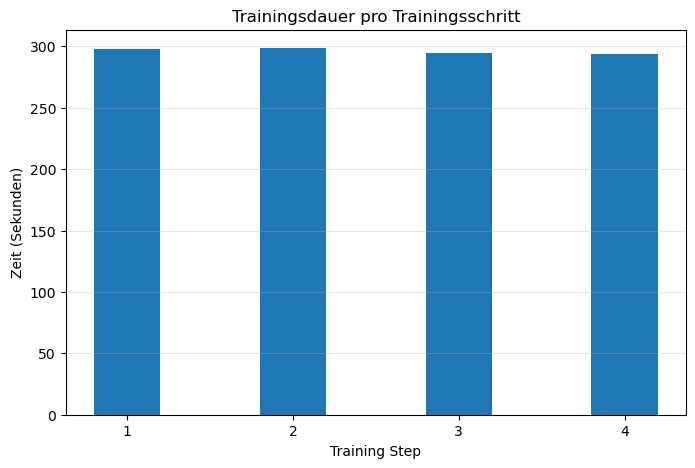

In [40]:
# Trainingsverläufe kombinieren
gesamt = {}

for key in training_1.history.keys():
    gesamt[key] = (
        training_1.history[key]
        + training_2.history[key]
        + training_3.history[key]
        + training_4.history[key]
    )


# Anzahl der Epochen bestimmen
epochs = range(1, len(gesamt["accuracy"]) + 1)


# Trainiingsverlauf für Accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs, gesamt["accuracy"], label="Training Accuracy")

if "val_accuracy" in gesamt:
    plt.plot(epochs, gesamt["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoche")
plt.ylabel("Accuracy")
plt.title("Trainingsverlauf: Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Trainingsverlauf für Loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, gesamt["loss"], label="Training Loss")

if "val_loss" in gesamt:
    plt.plot(epochs, gesamt["val_loss"], label="Validation Loss")

plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.title("Trainingsverlauf: Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Diagramm für Dauer pro Durchlauf
steps = [1, 2, 3, 4]
times = [time_1, time_2, time_3, time_4]

plt.figure(figsize=(8, 5))
plt.bar(steps, times, width = 0.4)

plt.xlabel("Training Step")
plt.ylabel("Zeit (Sekunden)")
plt.title("Trainingsdauer pro Trainingsschritt")
plt.xticks(steps)
plt.grid(axis="y", alpha=0.3)

plt.show()

## 6 Evaluation

In [26]:
# Trainingsdaten evaluieren
print('Performance auf Trainingsdaten:')
model_validieren.evaluate(x_train, y_train)

Performance auf Trainingsdaten:
1875/1875 [==============================] - 8s 4ms/step - loss: 0.0133 - accuracy: 0.9984


[0.013289296068251133, 0.9983500242233276]

In [27]:
# Testdaten evaluieren
print('Performance auf Testdaten:')
model_validieren.evaluate(x_test, y_test)

Performance auf Testdaten:
313/313 [==============================] - 1s 4ms/step - loss: 0.0367 - accuracy: 0.9944


[0.036671098321676254, 0.9944000244140625]

## 7 Modell speichern und laden

In [28]:
# Modell speichern
model_validieren.save('elma_model_neu.keras')

In [29]:
# Modell laden
model_laden = keras.models.load_model('elma_model_neu.keras')
model_laden.evaluate(x_test, y_test)

313/313 [==============================] - 1s 4ms/step - loss: 0.0367 - accuracy: 0.9944


[0.036671098321676254, 0.9944000244140625]

## 8 Vorhersagen und Fehlklassifikationen

In [41]:
# Trainingsdaten vorhersagen
vorhersage = model_validieren.predict(x_train)
fehler = [i for i in range(len(vorhersage)) if vorhersage[i].argmax() != y_train[i]]
print('Anzahl falscher Vorhersagen der Trainingsdaten:', len(fehler), '.',
      'Das sind', len(fehler) / len(vorhersage) * 100, '% der Daten.')

1875/1875 [==============================] - 7s 4ms/step
Anzahl falscher Vorhersagen der Trainingsdaten: 99 . Das sind 0.165 % der Daten.


In [43]:
# Testdaten vorhersagen
vorhersage_test = model_validieren.predict(x_test)
fehler_test = [i for i in range(len(vorhersage_test)) if vorhersage_test[i].argmax() != y_test[i]]
print('Anzahl falscher Vorhersagen der Testdaten:', len(fehler_test), '.',
      'Das sind', len(fehler_test) / len(vorhersage_test) * 100, '% der Daten.')
print(fehler_test[:50])

313/313 [==============================] - 1s 4ms/step
Anzahl falscher Vorhersagen der Testdaten: 56 . Das sind 0.5599999999999999 % der Daten.
[8, 247, 321, 326, 447, 947, 1014, 1112, 1232, 1242, 1260, 1393, 1459, 1901, 2053, 2118, 2129, 2130, 2182, 2293, 2414, 2462, 2597, 2654, 2771, 2896, 2939, 3073, 3422, 3520, 3926, 3941, 4740, 4761, 4823, 4860, 5165, 5936, 5937, 5955, 6166, 6172, 6576, 6597, 6755, 8092, 8376, 8408, 8527, 9015]


In [45]:
# Vorhersagewahrscheinlichkeit in Klassen umwandeln
y_vorhersage_test = pred_test.argmax(axis=1)

## 8.1 Zusätzliche Auswertungsplots

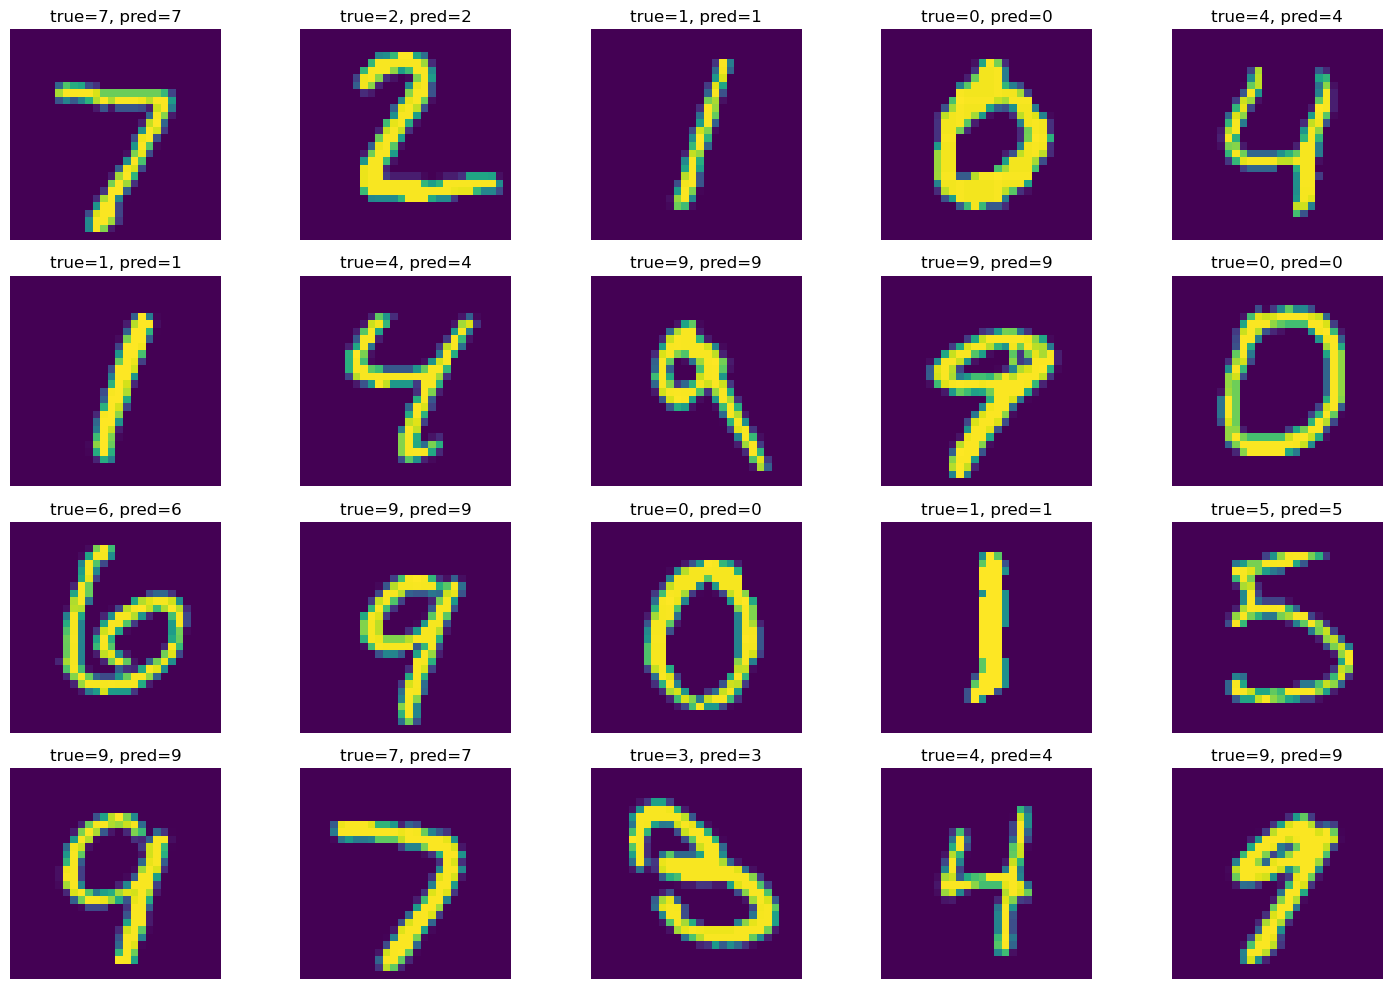

In [46]:
# Einige korrekt klassifizierte Ziffern anzeigen

korrekt = np.where(y_vorhersage_test == y_test)[0][:20]

fig = plt.figure(figsize=(15, 10))

for n, idx in enumerate(correct, start=1):
    ax = fig.add_subplot(4, 5, n)
    ax.imshow(np.squeeze(x_test[idx]))
    ax.axis("off")
    ax.set_title(f"true={y_test[idx]}, pred={y_vorhersage_test[idx]}")

plt.tight_layout()
plt.show()

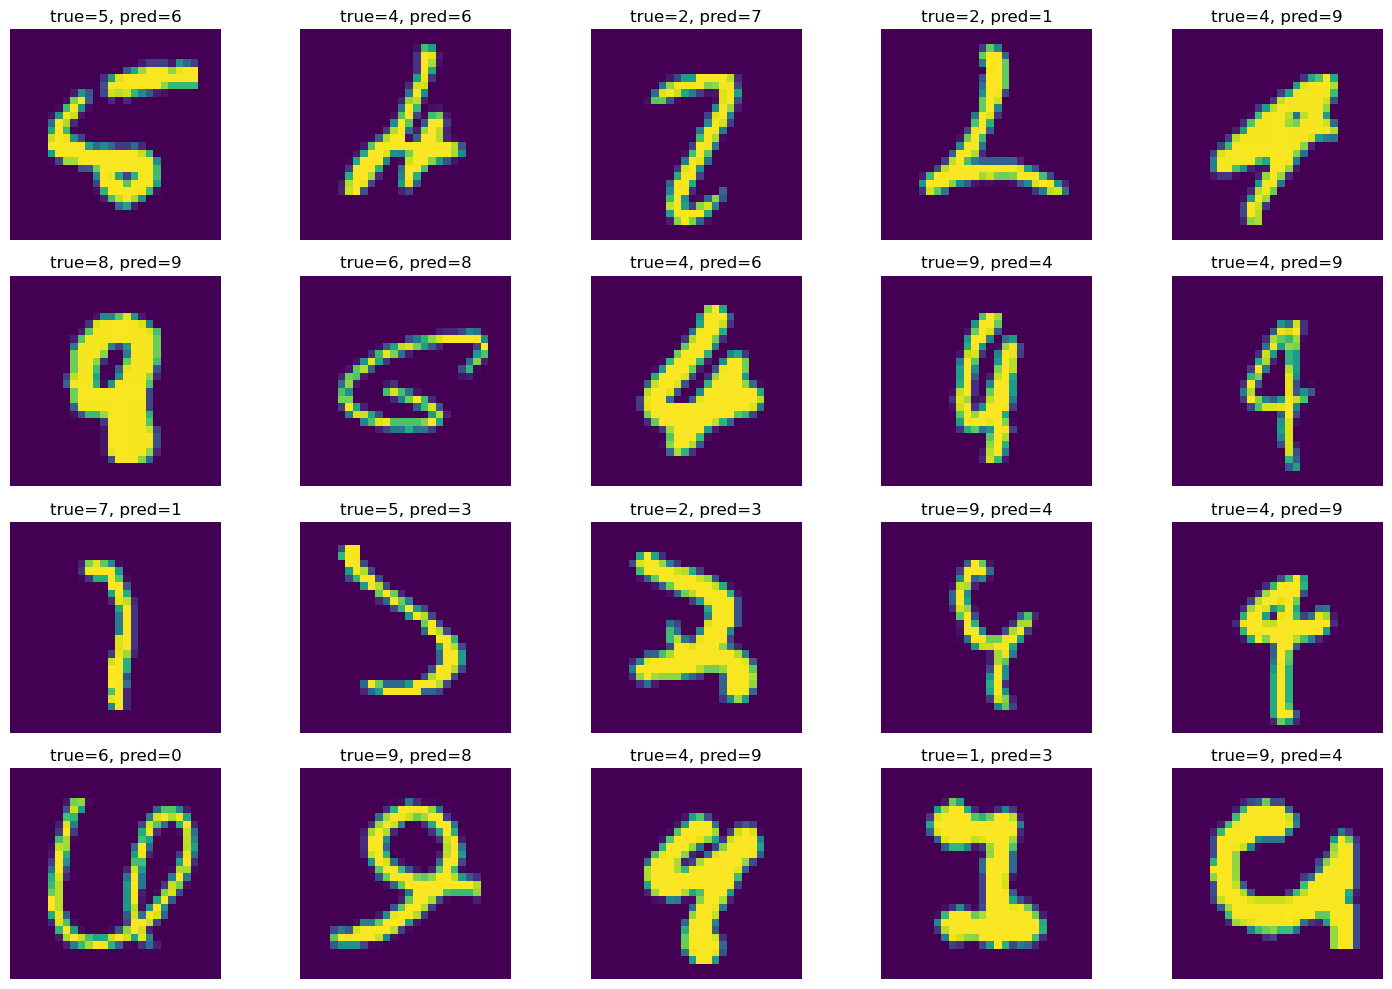

In [37]:
# Einige nicht korrekt klassifizierte Ziffern anzeigen
fig = plt.figure(figsize=(15, 10))
for n, idx in enumerate(wrong_test[:20], start=1):
    ax = fig.add_subplot(4, 5, n)
    ax.imshow(np.squeeze(x_test[idx]))
    ax.axis('off')
    ax.set_title(f'true={y_test[idx]}, pred={y_pred_test[idx]}')
plt.tight_layout()
plt.show()

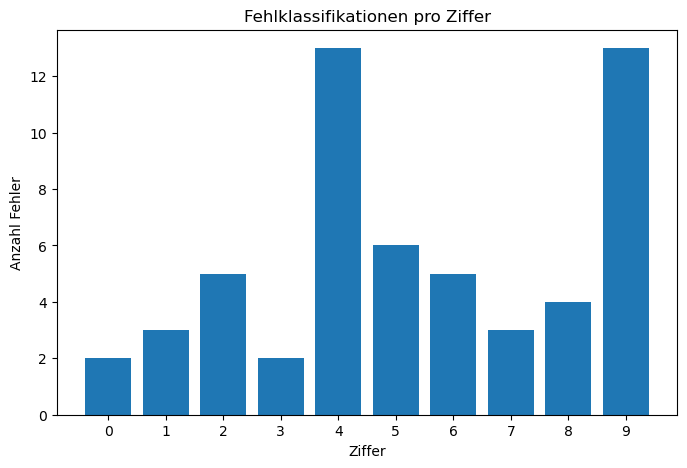

In [38]:
# Fehlerklassifikation pro Ziffer
wrong_test = np.where(y_pred_test != y_test)[0]
wrong_labels = y_test[wrong_test]

counts = np.bincount(wrong_labels, minlength=10)

plt.figure(figsize=(8, 5))
plt.bar(range(10), counts)

plt.xlabel("Ziffer")
plt.ylabel("Anzahl Fehler")
plt.title("Fehlklassifikationen pro Ziffer")
plt.xticks(range(10))

plt.show()